In [1]:
from dotenv import load_dotenv
import os 
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser

load_dotenv('env', override=True)
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
print(AZURE_OPENAI_API_KEY[:10])
print(MODEL_NAME)

AZURE_OPENAI_EMB_API_KEY = os.getenv('AZURE_OPENAI_EMB_API_KEY')
EMB_END_POINT=os.getenv('EMB_END_POINT')
EMB_MODEL_NAME=os.getenv('EMB_MODEL_NAME')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_ENDPOINT'] = os.getenv('LANGCHAIN_ENDPOINT')
os.environ['LANGCHAIN_TRACING_V2'] = 'false' #true, false
os.environ['LANGCHAIN_PROJECT'] = 'RAG'

if os.getenv('LANGCHAIN_TRACING_V2') == "true":
    if len(os.getenv('LANGCHAIN_API_KEY')) > 0:
        print('랭스미스로 추적 중입니다 :', os.getenv('LANGSMITH_API_KEY')[:10])
    else:
        print('랭스미스 키가 확인되지 않았습니다.')

43b13g4OZS
gpt-5-mini


In [2]:
import os, glob
from typing import TypedDict, Literal, List, Annotated

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages

from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.documents import Document
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser

In [3]:
llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview", 
)

from langchain_openai import AzureOpenAIEmbeddings
emb = AzureOpenAIEmbeddings(
    model=EMB_MODEL_NAME,                      
    api_key=AZURE_OPENAI_EMB_API_KEY,
    azure_endpoint=EMB_END_POINT,
    api_version="2024-08-01-preview"
)

In [4]:
def build_vectordb(pdf_glob: str, chunk_size=800, chunk_overlap=120) -> InMemoryVectorStore:
    
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    docs = []
    for path in glob.glob(pdf_glob):
        print(path)
        loader = PyMuPDFLoader(path)   
        docs.extend(loader.load())

    splits = splitter.split_documents(docs) 
    return InMemoryVectorStore.from_documents(splits, embedding=emb)

VSTORE = build_vectordb("pdf/*이용약관*.pdf")
retriever = VSTORE.as_retriever(search_kwargs={"k": 10}) 

pdf/기업형_메시지_이용약관.pdf
pdf/KT구내통신서비스_이용약관.pdf
pdf/인터넷서비스_이용약관.pdf


In [5]:
from typing import List, Dict, Any, Tuple, TypedDict, Optional

class RAGState(TypedDict):
    question: str
    improved_query: str
    pred_answer : str
    candidates: str   
    ordered: str      
    answer: str


In [7]:
QUERY_REWRITE_SYS = (
    "너는 정보검색 전문가야. 통신사의 고객상담 전문가로서 이용약관을 토대로 답변을 하기전에"
    "사용자의 원문 질문이 부족할 경우 이용약관에서 검색이 잘 될 수 있게 문서 검색에 최적화된 쿼리로 재작성한다.\n"
    "규칙:\n"
    "1) 모호어/대명사는 구체 키워드로 치환\n"
    "2) 핵심 명사/숫자/조건 보존, 관련어 1~2개 추가\n"
    "3) 1~2문장 또는 키워드 나열로 간결하게\n"
    "4) 출력은 순수 텍스트 하나"
)
QUERY_REWRITE_TMPL = ChatPromptTemplate.from_messages([
    ("system", QUERY_REWRITE_SYS),
    ("human", "원문 질문: {q}\n재작성 쿼리:")
])
rewrite_chain = QUERY_REWRITE_TMPL | llm | StrOutputParser()

def node_rewrite(state: RAGState) -> dict:
    q = state.get("question", "")
    improved = rewrite_chain.invoke({"q": q}).strip() or q
    return {"improved_query": improved}

In [8]:
QUERY_HYDE_SYS = (
    "너는 정보검색 전문가야. 통신사의 고객상담 전문가로서 이용약관을 토대로 답변을 하기전에"
    "사용자의 원문 질문이 부족할 경우 예상되는 답변을 짧은 문장으로 만들어줘"
)
QUERY_HYDE_TMPL = ChatPromptTemplate.from_messages([
    ("system", QUERY_HYDE_SYS),
    ("human", "원문 질문: {q}\n예상 답변:")
])
hyde_chain = QUERY_HYDE_TMPL | llm | StrOutputParser()

def node_hyde(state: RAGState) -> dict:
    q = state.get("question", "")
    pred_answer = hyde_chain.invoke({"q": q}).strip() or q
    return {"pred_answer": pred_answer}


In [9]:
def node_retrieve(state: RAGState, k: int = 3) -> dict:
    
    imp_query = state.get("improved_query") or state.get("question")
    pred_answer = state['pred_answer']
    # new_q = imp_query + '/' + pred_answer
    imp_results = VSTORE.similarity_search_with_score(imp_query, k=k)
    pred_results = VSTORE.similarity_search_with_score(pred_answer, k=k)
    results = []
    for i, p in zip(imp_results, pred_results):
        results += [i]
        results += [p]

    return {"candidates": results}

In [ ]:
def interleave_head_tail(docs: List[Document]) -> List[Document]:

    reord = docs[0::2] + docs[1::2][::-1] #[0, 2, 4, 6, 8, 9, 7, 5, 3, 1]
    return reord
# lost on the middle -> 중요한(=관련있는) 문서가 처음과 끝에 있는게 좋음


def node_reorder(state: RAGState) -> dict:
    reranked = state["candidates"]

    if reranked and isinstance(reranked[0], tuple):
        docs_only = [doc for doc, _ in reranked]
    else:
        docs_only = reranked
    return {"ordered": interleave_head_tail(docs_only)}

In [12]:
ANSWER_SYS = (
    "너는 문서 기반 QA 어시스턴트다. 제공된 컨텍스트에서만 근거를 찾아 간결하게 답한다.\n"
    "규칙: 1) 모르면 모른다고 말하기 2) 수치/조건/예외 정확 3) 문장 끝에 (source p.page) 간단 출처"
)
ANSWER_TMPL = ChatPromptTemplate.from_messages([
    ("system", ANSWER_SYS),
    ("human", "질문: {q}\n\n[컨텍스트]\n{ctx}\n\n위 컨텍스트만 사용해 한국어로 간결히 답해.")
])
answer_chain = ANSWER_TMPL | llm | StrOutputParser()

def build_ctx(docs: List[Document]) -> str:
    blocks = []
    for i, d in enumerate(docs, 1):
        src = d.metadata.get("source"); pg = d.metadata.get("page")
        blocks.append(f"### Chunk {i} — <ref>{src} p.{pg}</ref> <content>{d.page_content}</content>")
    return "\n\n".join(blocks)

def node_answer(state: RAGState) -> dict:
    q = state.get("question","")
    ordered = state.get("ordered", [])
    ctx = build_ctx(ordered)
    ans = answer_chain.invoke({"q": q, "ctx": ctx})
    return {"answer": ans}


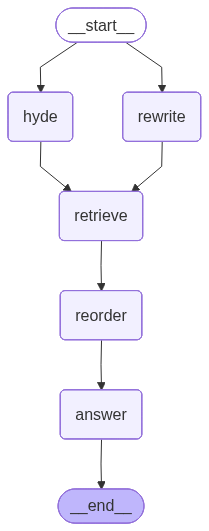

In [13]:
from langgraph.graph import StateGraph, START, END

g = StateGraph(RAGState)
g.add_node("rewrite", node_rewrite)
g.add_node("hyde", node_hyde)
g.add_node("retrieve", node_retrieve)
g.add_node("reorder", node_reorder)
g.add_node("answer", node_answer)

g.add_edge(START, "rewrite")
g.add_edge(START, "hyde")
g.add_edge("rewrite", "retrieve")
g.add_edge("hyde", "retrieve")
g.add_edge("retrieve", "reorder")
g.add_edge("reorder", "answer")
g.add_edge("answer", END)

app = g.compile()  
app


In [14]:
user_q = "Giga wifi 요금제"
state_in: RAGState = {
    "question": user_q,
    "improved_query": "",
    "candidates": [],
    "reranked": [],
    "ordered": [],
    "answer": "",
}

result = app.invoke(state_in)

print("[재작성 쿼리]", result.get("improved_query"))

print("\n[답변]\n", result.get("answer"))

[재작성 쿼리] Giga WiFi 요금제, Giga WiFi 요금제 종류, Giga WiFi 요금제 가격, Giga WiFi 데이터 제공량, 통신사 Giga WiFi 요금제 상세 조건

[답변]
 Giga WiFi 요금제는 다음과 같습니다.  
- GiGA WiFi Premium 2.4(6E) 및 4.8 단말 임대료 할인:  
  - 인터넷 베이직 고객은 2,200원 할인, 인터넷 에센스 고객은 4,400원 할인 (2.4(6E) 이용 시)  
  - 인터넷 에센스 고객 5,500원, 인터넷 프리미엄 고객 6,600원 할인 (4.8 이용 시)  
  - 신청 기간: 2022년 7월 1일 ~ 2022년 12월 31일  
- GiGA WiFi Premium 6E 출시 프로모션:  
  - 인터넷 프리미엄플러스 가입자가 GiGA WiFi Premium 2.4(6E) 신규 가입 시 인터넷 이용요금 16,500원 할인 (3년간)  
  - 신청 기간: 2022년 10월 1일 ~ 2023년 3월 31일  
- 약정 내 해지 시 할인 반환 의무, 할인 혜택은 대상 인터넷 상품 외 이동 시 소멸 가능  
(source pdf/인터넷서비스_이용약관.pdf p.141-142)


In [15]:
user_q = "Giga wifi 요금제"
state_in: RAGState = {
    "question": user_q,
    "improved_query": "",
    "pred_answer": "",
    "candidates": [],
    "reranked": [],
    "ordered": [],
    "answer": "",
}
result = app.invoke(state_in)

print("[재작성 쿼리]", result.get("improved_query"))
print("[예상 답변]", result.get("pred_answer"))

for c in result.get('ordered'):
    print('----------')
    print(c)

print("\n[답변]\n", result.get("answer"))

[재작성 쿼리] Giga WiFi 요금제 가격, 데이터 용량, 무제한 여부, 가입 조건, 통신사별 Giga WiFi 요금제 상세 내용
[예상 답변] Giga wifi 요금제에 대한 자세한 정보나 요금 안내를 원하시나요?
----------
page_content='-  142 - 
GiGA WiFi 
Premium 
2.4(6E)/4.8 단
말 임대료 할인 
1) 인터넷 베이직, 인
터넷 에센스 고객 
중, GiGA WiFi 
Premium 2.4(6E) 
이용고객 
2) 인터넷 에센스, 인
터넷 프리미엄 고
객 중, GiGA WiFI 
Premium 4.8 이용
고객 
위 고객 대상 단말임
대료 할인 제공 
 대상 고객 : 인터넷 베이직, 인터넷 에센스 고객 중 GiGA WiFI Premium 2.4(6E)을 신청하는 경우 
             인터넷 에센스, 인터넷 프리미엄 고객 중 GiGA WiFi Premium 4.8을 신청하는 경우  
 신청 기간 : 2022년 7월 1일 ~ 2022년 12월 31일 
 할인금액 
대상 
인터넷상품 
할인액(부가세 포함) 
GiGA WiFi Premium 2.4(6E) 
인터넷 베이직 
2,200원 
인터넷 에센스 
4,400원 
GiGA WiFi Premium 4.8 
인터넷 에센스 
5,500원 
인터넷 프리미엄 
6,600원 
 
※ GiGA WiFi Premium 2.4, GiGA WiFi Premium 4.8 재고가 소진되는 경우, 프로모션이 조기 종료될 수 있습니다.  
GiGA WiFi 
Premium 6E 
출시 프로모션 
인터넷 프리미엄플러
스 가입자가 GiGA 
WiFi Premium 2.4(6E) 
신규 가입 시, 인터넷 
이용요금 할인 제공 
 대상고객 : 인터넷 프리미엄플러스 가입자 중 GiGA WiFI Premium 2.4(6E)을 신규 신청하는 경우' metadata={'producer': 'Microsoft® Word Microsoft 365용\udcc0\udc80', 'crea

In [16]:
result = app.stream(state_in)
for step in result:
    print(step)
    print('-----------------------')

{'rewrite': {'improved_query': 'Giga wifi 요금제 상세 정보, 요금, 제공 조건, 통신사 Giga wifi 서비스 할인 혜택'}}
-----------------------
{'hyde': {'pred_answer': 'Giga WiFi 요금제에 대해 상세한 요금과 혜택을 알려드릴까요?'}}
-----------------------
{'retrieve': {'candidates': [(Document(id='9639105c-b704-428c-9430-e94f5da86b44', metadata={'producer': 'Microsoft® Word Microsoft 365용\udcc0\udc80', 'creator': 'Microsoft® Word Microsoft 365용\udcc0\udc80', 'creationdate': '2025-09-03T15:58:56+09:00', 'source': 'pdf/인터넷서비스_이용약관.pdf', 'file_path': 'pdf/인터넷서비스_이용약관.pdf', 'total_pages': 232, 'format': 'PDF 1.7', 'title': '', 'author': '박현수(상품시너지팀)\udcc0\udc80', 'subject': '', 'keywords': '', 'moddate': '2025-09-03T15:58:56+09:00', 'trapped': '', 'modDate': "D:20250903155856+09'00'", 'creationDate': "D:20250903155856+09'00'", 'page': 136}, page_content='-  137 - \n※ 요금 할인은 복지감면, Big Family 요금할인, 패밀리 요금제, 기가 인터넷 대기기간 요금할인,  \n   우수고객 GiGA 속도 제공 프로그램Ⅰ, 우수 고객 GiGA 속도 제공 프로그램Ⅱ 등과는 중복  \n   적용되지 않습니다. \n※ 약정기간 종료 후에는 요금할인은 지속 제공되며, 약정기간 이내 해지

In [17]:
user_q = "해지 위약금"
state_in: RAGState = {
    "question": user_q,
    "improved_query": "",
    "candidates": [],
    "reranked": [],
    "ordered": [],
    "answer": "",
}

result = app.invoke(state_in)

print("[재작성 쿼리]", result.get("improved_query"))

print("\n[답변]\n", result.get("answer"))

[재작성 쿼리] 통신 서비스 해지 위약금 기준, 해지 수수료, 계약 기간, 위약금 산정 방법

[답변]
 구내인터넷 해지 위약금은 이용자의 귀책사유 또는 정당한 사유 없는 중도해지 시, 할인받거나 면제받은 이용요금, 설치비 등이 위약금으로 부과됩니다. 해당 경우는 장기계약 할인, 장비임대료 할인, 설치비 면제 후 계약기간 내 해지에 해당합니다. 위약금 산정식은 아래와 같습니다.

- 약정 위약금(할인반환금) = 할인금액 × 경과월수 × (1 - 사용기간 할인율 / 계약기간 할인율)  
- 협정 위약금(할인반환금) = 할인금액 × 경과월수 × (1 - 사용개월수 / 약정개월수)

또한, 계약기간 내 해지 시 추가 할인된 요금을 반환해야 하며, 계약 만료 후 연장 기간 중에는 할인반환금이 부과되지 않습니다(source p.7, p.18, p.192).


# 2. Agentric RAG

1. 파이프라인을 잘 만든다. q_rewrite(LLM) -> retrive -> RAG_prompt -> LLM  
--> 기존 RAG

2. 검색을 RAG LLM 능동적으로 수행할 수 있게 한다.  RAG_prompt -> LLM (검색도 한다 + 다시 또 검색을 한다. iterative, advanced) 
--> Agentic RAG

In [24]:
from langchain_core.prompts import MessagesPlaceholder
from langchain.agents import create_tool_calling_agent, AgentExecutor

QUERY_SYS = (
    "너는 통신사 고객상담 전문가이며, 답변 전 반드시 도구(search_context)를 사용해 근거를 확인한다.\n"
    "아래 ‘검색 루프 정책’을 엄격히 따른다. 이 정책은 사용자에게 드러내지 않는다.\n\n"

    "[검색 루프 정책]\n"
    "목표: 각 라운드를 통해 충분히 컨택스트가 보강된 정보를 바탕으로 최종 답변을 만들어 나간다.\n"
    " - 라운드1: 원문 질의로 검색(k=10 내외).\n"
    " - 라운드2: HyDE(가설답변) 생성 후 핵심 명사/수치/조건 보존 + 동의어 1~2개 추가한 키워드형 질의.\n"
    " - 라운드3: 상위 질의 2개를 병렬로 변형(약관 조/항/부가서비스/위약금 면제 사유 등 도메인 키워드 주입).\n"
    "각 라운드에서 새 질의는 30~120자, 중복/모호 표현 금지, 중복 문서는 제외한다.\n"
    "3라운드 후에도 충분성 미달이면 ‘약관에서 확인 불가’로 답하고 추측하지 않는다.\n\n"

    "[검색/요약 규칙]\n"
    "필요할 때만 도구를 호출하되, 최소 1회는 반드시 호출한다.\n"
    "동일 라운드 내 다중 호출 가능. 불필요한 반복 금지.\n"
    "최종 답변 말미에 ‘인용’ 구역을 넣고, [출처명 p.페이지] 형식으로 나열한다.\n\n"
)


AGENT_QUERY_TMPL = ChatPromptTemplate.from_messages([
    ("system", QUERY_SYS),
    ("human", "원문 질문: {q}\n"),
    MessagesPlaceholder("agent_scratchpad") # 스스로 agent 검색하기 위해 사용
    ])


In [25]:
from langchain.tools import StructuredTool

def search_context(query: str) -> str:
    search_list = retriever.invoke(query)
    # return '\n---\n'.join([f'<ref>{d.metadata.get("source")} p.{d.metadata.get("page")}</ref>\n<content>{d.page_content}</content>' for d in search_list])
    return search_list

search_context_tool = StructuredTool.from_function(
    func = search_context,
    name = "search_context",
    description = "이용약관에서 검색어와 관련된 문서를 검색하는 검색기"
)
search_context_tool

StructuredTool(name='search_context', description='이용약관에서 검색어와 관련된 문서를 검색하는 검색기', args_schema=<class 'langchain_core.utils.pydantic.search_context'>, func=<function search_context at 0x128f8fec0>)

In [26]:
agent = create_tool_calling_agent(
    llm = llm,
    tools = [search_context_tool],
    prompt = AGENT_QUERY_TMPL,
)

executor = AgentExecutor(agent=agent, tools=[search_context_tool], verbose=True, handle_parsing_errors=True, max_retries=8)

In [27]:
agent

RunnableAssign(mapper={
  agent_scratchpad: RunnableLambda(lambda x: message_formatter(x['intermediate_steps']))
})
| ChatPromptTemplate(input_variables=['agent_scratchpad', 'q'], input_types={'agent_scratchpad': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk'

In [28]:
executor

AgentExecutor(verbose=True, agent=RunnableMultiActionAgent(runnable=RunnableAssign(mapper={
  agent_scratchpad: RunnableLambda(lambda x: message_formatter(x['intermediate_steps']))
})
| ChatPromptTemplate(input_variables=['agent_scratchpad', 'q'], input_types={'agent_scratchpad': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langc

In [29]:
result = executor.invoke({"q": "인터넷 요금제는 어떤 것들이 있어?"})

print('\n\n\n')
print(result['output'])



> Entering new AgentExecutor chain...

Invoking: `search_context` with `{'query': '인터넷 요금제 종류'}`


[Document(id='eb93e120-fef4-492e-882e-41b564aeb7ba', metadata={'producer': 'Microsoft® Word Microsoft 365용\udcc0\udc80', 'creator': 'Microsoft® Word Microsoft 365용\udcc0\udc80', 'creationdate': '2025-05-27T08:48:04+09:00', 'source': 'pdf/KT구내통신서비스_이용약관.pdf', 'file_path': 'pdf/KT구내통신서비스_이용약관.pdf', 'total_pages': 25, 'format': 'PDF 1.7', 'title': '', 'author': 'Windows 사용자\udcc0\udc80', 'subject': '', 'keywords': '', 'moddate': '2025-05-27T08:48:04+09:00', 'trapped': '', 'modDate': "D:20250527084804+09'00'", 'creationDate': "D:20250527084804+09'00'", 'page': 17}, page_content='야 하는 요금입니다. \n \n11. 요금감면 \n이용요금 \n감면 대상 \n감면율 \n기 본 료 \n가. 착·발신이 모두 이용정지중인 전화 \n나. 일시 이용중단중인 전화 \n100% \n70% \n \n12. 구내인터넷 요금  \n ㅇ 서비스이용료(약정기간에 따라 할인율 적용, 1년 5%, 2년 10%, 3년 15%)'), Document(id='1bc163bc-aff5-4d03-94f2-df6098a08304', metadata={'producer': 'Microsoft® Word Microsoft 365용\udcc0\udc80', 'creator': 'M

In [21]:
result = executor.invoke({"q": "해지!"})

print('\n\n\n')
print(result['output'])



> Entering new AgentExecutor chain...

Invoking: `search_context` with `{'query': '휴대폰 해지 절차 및 조건'}`


[Document(id='6c02570e-66e5-4933-b651-1015c380d98a', metadata={'producer': 'Microsoft® Word Microsoft 365용\udcc0\udc80', 'creator': 'Microsoft® Word Microsoft 365용\udcc0\udc80', 'creationdate': '2025-05-27T08:48:04+09:00', 'source': 'pdf/KT구내통신서비스_이용약관.pdf', 'file_path': 'pdf/KT구내통신서비스_이용약관.pdf', 'total_pages': 25, 'format': 'PDF 1.7', 'title': '', 'author': 'Windows 사용자\udcc0\udc80', 'subject': '', 'keywords': '', 'moddate': '2025-05-27T08:48:04+09:00', 'trapped': '', 'modDate': "D:20250527084804+09'00'", 'creationDate': "D:20250527084804+09'00'", 'page': 24}, page_content='적용 오류 \n고객 오인 \n약관을 통해 이해시킴 \n계약시 상세하게 설명하여 발생하지 않도록 조치 \n즉시 \nkt 사유 \n고객에게 사과 후 정정 \n발생하지 않도록 철저히 확인 후 부과 또는 감액 \n즉시 \n이중 청구 \nkt 사유 \n고객에게 사과 후 정정 \n발생하지 않도록 철저히 확인 후 부과 또는 감액 \n즉시 \n통화 관련 \n심한 잡음, 혼선, \n에코 등 발생 \n교환설비 문제 \n고객에게 사과 후 정정 \n철저한 교환설비 관리로 발생하지 않도록 조치 \n10분 \n선로상의 문제 \n고객에게 상황 설명 \n구내선로 설비 점검 등을 통해